# Phase 4 — Emissions & Deposition Stubs

Verifies surface emission and dry deposition rate parameterizations on the
`chapman_emis_dep` mechanism, which extends the Chapman photochemistry with
two test species:

| Species | Emission flux (molec cm⁻² s⁻¹) | Deposition v_d (cm s⁻¹) | Expected behaviour |
|---------|--------------------------------|--------------------------|-------------------|
| `foo`   | 1 × 10¹² | — | Monotonic accumulation |
| `bar`   | 5 × 10¹¹ | 1.0 | Approach emission–deposition equilibrium |

### Checks
| # | Test | Criterion |
|---|------|-----------|
| 1 | Species present | `foo` and `bar` in output; Chapman species `o3, o, o1d` also present |
| 2 | `foo` accumulates | Surface-level mean increases monotonically |
| 3 | `bar` approaches equilibrium | Surface-level mean growth rate decelerates (d²bar/dt² < 0) |
| 4 | Chapman O₃ still physical | 0 < max(O₃) < 1e-3 kg/kg |

**Prerequisite:** `scripts/run_jw_test.sh 1 chapman_emis_dep → data/jw_480km_chapman_emis_dep/output.nc`

In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "jw_480km_chapman_emis_dep"
OUTPUT = DATA_DIR / "output.nc"
assert OUTPUT.exists(), f"Run the Phase 4 test first — {OUTPUT} not found"

ds = nc.Dataset(OUTPUT)
lat = np.degrees(ds["latCell"][:])
lon = np.degrees(ds["lonCell"][:])
nTimes = ds.dimensions["Time"].size
nVertLevels = ds["foo"].shape[2]  # (Time, nCells, nVertLevels)
print(f"Output: {nTimes} time steps, {len(lat)} cells, {nVertLevels} levels")

results = {}  # test_name → bool

Output: 25 time steps, 2562 cells, 26 levels


## Test 1 — Expected species present

The `chapman_emis_dep` mechanism should produce `foo`, `bar` (emission/deposition
test species) plus the Chapman species `o3`, `o`, `o1d`.

In [2]:
EXPECTED = {"foo", "bar", "o3", "o", "o1d"}
present = EXPECTED & set(ds.variables.keys())
missing = EXPECTED - present

print(f"Expected species: {sorted(EXPECTED)}")
print(f"Present:          {sorted(present)}")
print(f"Missing:          {sorted(missing) if missing else '(none)'}")

ok = len(missing) == 0
results["species_present"] = ok
print(f"\n{'PASS' if ok else 'FAIL'}: All expected species present")

Expected species: ['bar', 'foo', 'o', 'o1d', 'o3']
Present:          ['bar', 'foo', 'o', 'o1d', 'o3']
Missing:          (none)

PASS: All expected species present


## Test 2 — `foo` accumulates monotonically

`foo` receives a constant surface emission flux (1 × 10¹² molec cm⁻² s⁻¹) with
no deposition or chemical loss.  Its domain-mean mixing ratio at the surface
level should increase at every output timestep.

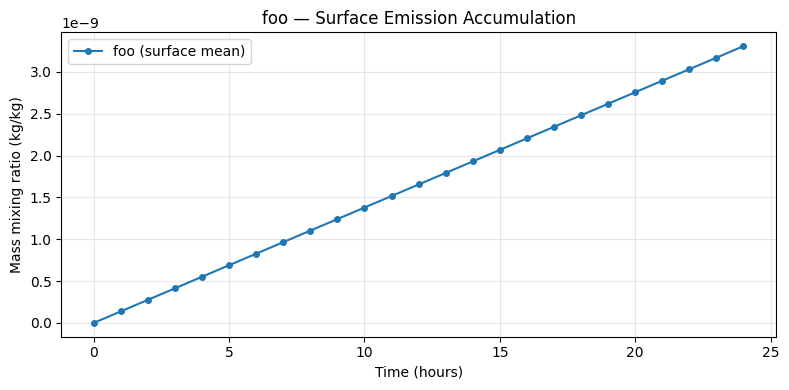

foo surface mean: initial = 0.000e+00, final = 3.308e-09
All increments non-negative: True

PASS: foo accumulates monotonically


In [3]:
# Surface level is k=0 in this MPAS output (vertical levels increase upward).
foo_sfc = np.array([ds["foo"][t, :, 0].mean() for t in range(nTimes)])

fig, ax = plt.subplots(figsize=(8, 4))
hours = np.arange(nTimes)  # output every hour
ax.plot(hours, foo_sfc, "o-", markersize=4, label="foo (surface mean)")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Mass mixing ratio (kg/kg)")
ax.set_title("foo — Surface Emission Accumulation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check monotonic increase (skip t=0 which is zero)
diffs = np.diff(foo_sfc[1:])  # ignore first step in case output at t=0 is zeros
monotonic = np.all(diffs >= 0.0) and foo_sfc[-1] > 0.0
results["foo_accumulates"] = monotonic
print(f"foo surface mean: initial = {foo_sfc[0]:.3e}, final = {foo_sfc[-1]:.3e}")
print(f"All increments non-negative: {np.all(diffs >= 0.0)}")
print(f"\n{'PASS' if monotonic else 'FAIL'}: foo accumulates monotonically")


## Test 3 — `bar` approaches equilibrium

`bar` receives surface emissions (5 × 10¹¹ molec cm⁻² s⁻¹) but also suffers
first-order dry deposition with v_d = 1.0 cm s⁻¹.  As `bar` concentration
builds up, the deposition loss rate increases until it balances the emission
source.  The domain-mean growth rate should decelerate (d²bar/dt² < 0).

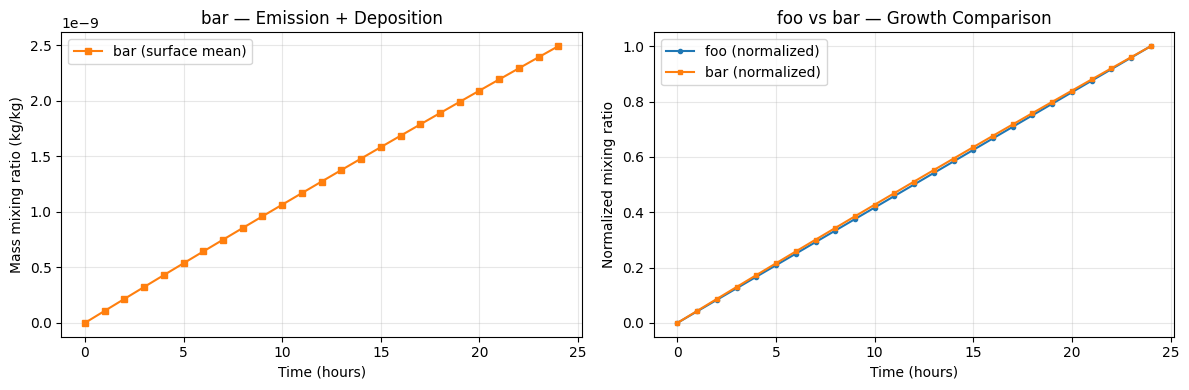

bar surface mean: initial = 0.000e+00, final = 2.492e-09
Mean acceleration (2nd half): -3.683e-13

PASS: bar approaches equilibrium


In [4]:
bar_sfc = np.array([ds["bar"][t, :, 0].mean() for t in range(nTimes)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar time series
axes[0].plot(hours, bar_sfc, "s-", markersize=4, color="C1", label="bar (surface mean)")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Mass mixing ratio (kg/kg)")
axes[0].set_title("bar — Emission + Deposition")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: foo and bar together (normalized)
axes[1].plot(hours, foo_sfc / max(foo_sfc[-1], 1e-30), "o-", markersize=3, label="foo (normalized)")
axes[1].plot(hours, bar_sfc / max(bar_sfc[-1], 1e-30), "s-", markersize=3, label="bar (normalized)")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Normalized mixing ratio")
axes[1].set_title("foo vs bar — Growth Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check that growth rate decelerates: d²(bar)/dt² < 0 for later timesteps
# Use the last half of the time series
mid = max(nTimes // 2, 2)
bar_rate = np.diff(bar_sfc)          # d(bar)/dt
bar_accel = np.diff(bar_rate)        # d²(bar)/dt²
deceleration = np.mean(bar_accel[mid-1:]) < 0 if len(bar_accel) > mid else True
results["bar_equilibrium"] = deceleration and bar_sfc[-1] > 0.0
print(f"bar surface mean: initial = {bar_sfc[0]:.3e}, final = {bar_sfc[-1]:.3e}")
print(f"Mean acceleration (2nd half): {np.mean(bar_accel[mid-1:]):.3e}")
print(f"\n{'PASS' if results['bar_equilibrium'] else 'FAIL'}: bar approaches equilibrium")


## Test 4 — Chapman O₃ still physical

The emission/deposition test species should not interfere with Chapman
photochemistry.  O₃ should remain positive and within a physically meaningful
range after 1 day.

In [5]:
o3 = ds["o3"][-1, :, :]  # last timestep
o3_min = float(np.min(o3))
o3_max = float(np.max(o3))
print(f"O₃ at final timestep: min = {o3_min:.3e}, max = {o3_max:.3e} kg/kg")

ok = o3_min >= 0.0 and o3_max > 0.0 and o3_max < 1e-3
results["chapman_o3"] = ok
print(f"\n{'PASS' if ok else 'FAIL'}: Chapman O₃ still physical")

O₃ at final timestep: min = 4.966e-08, max = 6.872e-05 kg/kg

PASS: Chapman O₃ still physical


## Summary

In [6]:
ds.close()

print("=" * 50)
print("Phase 4 Verification Results")
print("=" * 50)
all_pass = True
for name, passed in results.items():
    status = "PASS" if passed else "FAIL"
    print(f"  {status}: {name}")
    if not passed:
        all_pass = False
print("=" * 50)
print(f"Overall: {'ALL TESTS PASSED' if all_pass else 'SOME TESTS FAILED'}")
assert all_pass, "Phase 4 verification failed"

Phase 4 Verification Results
  PASS: species_present
  PASS: foo_accumulates
  PASS: bar_equilibrium
  PASS: chapman_o3
Overall: ALL TESTS PASSED
